# Traitement sitadel

In [112]:
!pip install -r requirements.txt

In [113]:
%run Sitadel2_traitement.py

/home/onyxia/work/projet3A/Sitadel2_traitement.py:22: DtypeWarning: Columns (0,2,4,7,11,17,19,20,21,23,29,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(tmp, sep=";")
/home/onyxia/work/projet3A/Sitadel2_traitement.py:90: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1000["ANNEE_REELLE_AUTORISATION"] = pd.to_datetime(


Lancement de la requête BAN
df_ban
                                                 adresse  ...  code_com_BAN
6923                       133 RUE LECOCQ 33000 BORDEAUX  ...         33063
8344                   181 RUE DE CHATILLON 35000 RENNES  ...         35238
25320              282 RUE FRANCOIS PERRIN 87000 LIMOGES  ...         87085
602               606 BOULEVARD DU MERCANTOUR 06200 NICE  ...         06088
23155              501 CHAUSSEE JULES FERRY 80090 AMIENS  ...         80021
...                                                  ...  ...           ...
25847   26 RUE HENRI-AUGUSTE-DESB 0<NA> CORBEIL ESSONNES  ...           NaN
25897                   1 ROND-POINT L'ESPACE 91007 EVRY  ...           NaN
26064                                       0<NA> SACLAY  ...           NaN
26200        RUE HENRI FABRE -PRES D'ANTONY 0<NA> ANTONY  ...           NaN
26427  ""LES BRUYERES"" RUE DU PAVE 93290 TREMBLAY-EN...  ...           NaN

[24209 rows x 6 columns]
df_loc
       DEP_CODE  ...

# Traitement BDTopo

In [114]:
import importlib
import credentials
import BDTopo_fonctions
importlib.reload(credentials)
importlib.reload(BDTopo_fonctions)
from credentials import s3
from BDTopo_fonctions import load_gpkg
from BDTopo_fonctions import download_to_SSPCloud
from BDTopo_fonctions import upload_to_onyxia

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_all_1000m3.gpkg")

Téléchargement depuis mgarbe/BDTOPO/BDTOPO_BATI_merge_dep_all_1000m3.gpkg ...
Chargement réussi (4120762 lignes)


In [115]:
#meilleure estimmation de l'apparition du bati
gdf["DATE_CREAT"] = pd.to_datetime(gdf["DATE_CREAT"], errors="coerce").dt.year.astype('Int64')
gdf["Apparition_BDTopo"] = gdf[["Annee", "DATE_CREAT"]].min(axis=1)

# Initialisation des temp pour appariement

In [116]:
from concurrent.futures import ProcessPoolExecutor
import pandas as pd
from multiprocessing import Manager
from appariement_Sitadel_BDTopo_fonctions import run_batch

#batchs
deps = sorted(gdf["Dep"].unique())
batch_size = 10
batches = [deps[i:i+batch_size] for i in range(0, len(deps), batch_size)]
results = []

#traitement
total_deps = len(deps)
deps_traites = 0

#queue partagée pour affichage en temp réel
manager = Manager()
queue = manager.Queue()

with ProcessPoolExecutor() as exe:
    futures = [exe.submit(run_batch, gdf, batch, batch_num+1, queue)
               for batch_num, batch in enumerate(batches)]

    # Lecture de la queue en temps réel
    while any(f.done() is False for f in futures) or not queue.empty():
        while not queue.empty():
            deps_traites += queue.get()
            print(f"\r{deps_traites}/{total_deps} départements traités", end="", flush=True)

    # Récupération des résultats finaux
    for fut in futures:
        results.append(fut.result())

print("\nTraitement terminé !")

#fusion
temp_BDTopo = pd.concat(results, ignore_index=True)



27/94 départements traités

IOStream.flush timed out


31/94 départements traités

IOStream.flush timed out


94/94 départements traités
Traitement terminé !


In [117]:
seuil_dep=96

In [118]:
#from appariement_Sitadel_BDTopo_fonctions import nouveaux_batiments
#temp_BDTopo=nouveaux_batiments(gdf[gdf["Dep"]<seuil_dep])

# Créer la colonne Apparition_BDTopo : max entre Annee et DATE_CREAT, en ignorant les NaN
#temp_BDTopo["DATE_CREAT"] = pd.to_datetime(temp_BDTopo["DATE_CREAT"], errors="coerce").dt.year
#temp_BDTopo["Apparition_BDTopo"] = pd.concat([temp_BDTopo["Annee"], annee_date_creat], axis=1).max(axis=1)

In [119]:
#geoloc des batîments nouveaux
#import importlib
#import Sitadel2_fonctions
#importlib.reload(Sitadel2_fonctions)
#from Sitadel2_fonctions import reverse_geocode
#temp_BDTopo=reverse_geocode(temp_BDTopo)

In [120]:
#temp_sit=df1000[df1000["DEP_CODE"]<seuil_dep]

In [121]:
temp_sit=df1000.copy()

In [122]:
temp_sit['SURF_CREEE'] = temp_sit[['SURF_IND_CREEE', 'SURF_ENT_CREEE', 'SURF_COM_CREEE']].sum(axis=1)
temp_sit = temp_sit[[
    "ANNEE_REELLE_AUTORISATION",
    "DEP_CODE",
    "COMM",
    "DATE_REELLE_AUTORISATION",
    "DATE_REELLE_DOC",
    "DATE_REELLE_DAACT",
    "SURF_CREEE",
    "I_EXTENSION",
    "DESTINATION_PRINCIPALE",
    "adresse",
    "adresse_BAN",
    "lat_BAN",
    "lon_BAN",
    "code_com_BAN",
    "score_BAN"
]]

# Identification des PC localisables

### Appariement Sitadel2 - BDTOPO dans un objectif d'affiner la localisation de Sitadel

In [123]:
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd
import numpy as np
import re

# ---------------------------
# 1. Préparer GeoDataFrames
# ---------------------------
temp_sit = temp_sit.copy()
temp_sit['geometry'] = temp_sit.apply(lambda r: Point(r["lon_BAN"], r["lat_BAN"]), axis=1)
temp_sit = gpd.GeoDataFrame(temp_sit, geometry="geometry", crs="EPSG:4326")

sit_remaining = temp_sit.index.to_list()  # tous les indices
sit_no_candidate = set()  # indices à ignorer
tour = 0

temp_BDTopo = temp_BDTopo.copy()
if temp_BDTopo.crs is None:
    raise ValueError("temp_BDTopo n'a pas de CRS défini")

# Projection commune en Lambert 93 pour calcul de distances
temp_sit = temp_sit.to_crs(epsg=2154)
temp_BDTopo = temp_BDTopo.to_crs(epsg=2154)

# ---------------------------
# 2. Colonnes de résultats
# ---------------------------
temp_sit["match_temp"] = None
temp_sit["best_temp_idx"] = None
temp_sit["lat_BDTOPO"] = None
temp_sit["lon_BDTOPO"] = None
temp_sit["geometry_BDTOPO"] = None

# ---------------------------
# 3. Boucle globale itérative
# ---------------------------
sit_remaining = temp_sit.index.to_list()  # indices non matchés
tour = 0

while sit_remaining:
    print(f"\rTour {tour+1}, lignes restantes à matcher : {len(sit_remaining)}", end="", flush=True)
    matches_this_round = []

    # --- Étape 1 : calculer tous les matchs possibles ---
    for idx_sit in sit_remaining:
        if idx_sit in sit_no_candidate:
            continue  # ignorer ceux sans candidat du tour précédent

        row = temp_sit.loc[idx_sit]
        point = row.geometry
        code_dep = row.get("DEP_CODE", None)
        surf = row.get("SURF_CREEE", None)
        annee_sit = row["ANNEE_REELLE_AUTORISATION"]
        adresse_ban = row.get("adresse_BAN", "") or ""

        candidats = temp_BDTopo[temp_BDTopo["Dep"] == code_dep]
        candidats = candidats[candidats["Apparition_BDTopo"] >= annee_sit]
        if candidats.empty:
            sit_no_candidate.add(idx_sit)  # pas de candidat possible, ne plus tester
            continue

        # Rayon selon adresse
        if re.match(r"^\s*\d+", adresse_ban):
            rayons = [100,200,300]
        else:
            rayons = [500, 1000, 1500, 2000, 2500, 3000, 3500]

        best_idx = None
        best_dist = np.inf
        best_rayon = None

        for rayon in rayons:
            buffer = point.buffer(rayon)
            candidats_buf = candidats[candidats.geometry.intersects(buffer)]
            if candidats_buf.empty:
                continue

            # Filtre sur surface ±50%
            if surf is not None:
                candidats_buf = candidats_buf.copy()
                candidats_buf["aire"] = candidats_buf.geometry.area
                candidats_buf = candidats_buf[
                    (candidats_buf["aire"] >= 0.7 * surf) &
                    (candidats_buf["aire"] <= 1.3 * surf)
                ]
                if candidats_buf.empty:
                    continue

            # Filtre sur année la plus proche
            candidats_buf = candidats_buf.copy()
            candidats_buf["diff_annee"] = abs(candidats_buf["Annee"] - annee_sit)
            min_diff = candidats_buf["diff_annee"].min()
            candidats_buf = candidats_buf[candidats_buf["diff_annee"] == min_diff]

            # Sélection du plus proche (distance)
            distances = candidats_buf.geometry.distance(point)
            if not distances.empty:
                candidate_idx = distances.idxmin()
                candidate_dist = distances[candidate_idx]
                if candidate_dist < best_dist:
                    best_dist = candidate_dist
                    best_idx = candidate_idx
                    best_rayon = rayon

        if best_idx is not None:
            matches_this_round.append({
                "sit_idx": idx_sit,
                "temp_idx": best_idx,
                "rayon": best_rayon,
                "dist": best_dist
            })

    if not matches_this_round:
        break  # plus de matchs possibles

    # --- Étape 2 : résoudre les doublons sur temp_idx ---
    df_matches = pd.DataFrame(matches_this_round)
    if not df_matches.empty:
        duplicates_temp = df_matches[df_matches.duplicated(subset=["temp_idx"], keep=False)]

        for temp_idx in duplicates_temp["temp_idx"].unique():
            subset = df_matches[df_matches["temp_idx"] == temp_idx]
            if subset.empty or subset["dist"].dropna().empty:
                continue
            best_row = subset.loc[subset["dist"].idxmin()]

            # réinitialiser les autres sit_idx
            other_sits = subset["sit_idx"].tolist()
            other_sits.remove(best_row["sit_idx"])
            temp_sit.loc[other_sits, ["match_temp", "best_temp_idx", "lat_BDTOPO", "lon_BDTOPO", "geometry_BDTOPO"]] = None

            # ne garder que le meilleur
            df_matches = df_matches.drop(subset.index.difference([best_row.name]))

    # --- Étape 3 : enregistrer les matchs validés ---
    for _, m in df_matches.iterrows():
        idx_sit = m["sit_idx"]
        best_idx = m["temp_idx"]
        rayon = m["rayon"]

        temp_sit.at[idx_sit, "match_temp"] = rayon
        temp_sit.at[idx_sit, "best_temp_idx"] = best_idx

        geom_temp = temp_BDTopo.loc[best_idx, "geometry"]
        temp_sit.at[idx_sit, "geometry_BDTOPO"] = geom_temp
        temp_sit.at[idx_sit, "Apparition_BDTopo"] = temp_BDTopo.loc[best_idx, "Apparition_BDTopo"]

        centroid = geom_temp.centroid
        centroid_wgs = gpd.GeoSeries([centroid], crs="EPSG:2154").to_crs("EPSG:4326").iloc[0]
        temp_sit.at[idx_sit, "lat_BDTOPO"] = centroid_wgs.y
        temp_sit.at[idx_sit, "lon_BDTOPO"] = centroid_wgs.x

    # --- Étape 4 : supprimer temp_BDTopo déjà matchés ---
    temp_BDTopo = temp_BDTopo.drop(index=df_matches["temp_idx"].unique())

    # --- Étape 5 : mettre à jour sit_remaining ---
    sit_remaining = [
        idx for idx in sit_remaining
        if temp_sit.at[idx, "best_temp_idx"] is None and idx not in sit_no_candidate
    ]

    tour += 1

temp_sit["geometry_BDTOPO"] = gpd.GeoSeries(temp_sit["geometry_BDTOPO"], crs="EPSG:2154")
print("\nMatching terminé.")



Tour 5, lignes restantes à matcher : 17273
Matching terminé.


In [124]:
sauv_temp_sit=temp_sit.copy()
sauv_temp_BDTopo=temp_BDTopo.copy()

### Définition des PC dits "identifiables" : 4 possibilités dont le succès d'appariement avec BDTopo 

In [172]:
temp_sit=sauv_temp_sit.copy()
temp_BDTopo=sauv_temp_BDTopo.copy()

In [173]:
# ON SELECTIONNE LES PC LOCALISABLES (pcq Sitadel précis ou pcq appariement BDTOPO) 

#condition 1 : l'adresse Sitadel et BAN ont toutes deux un numéro de voie 
condition1=(temp_sit["adresse_BAN"].astype(str).str.match(r"^\d")) & (temp_sit["adresse"].astype(str).str.match(r"^\d"))

#condition 2 : pas 1 & tb score BAN & date d'ouverture du chantier dispo & surface créee supérieure à 3000m2 (on veut éviter d'exclure trop facilement ces surfaces 
# + être précis sur la localisation (ex : num de rue) importe moins puisque la surface est grande)
condition2=(~condition1) & (temp_sit["score_BAN"]>0.9) & (temp_sit["DATE_REELLE_DOC"].notna()) & (temp_sit["SURF_CREEE"]>3000)

#condition 3 : pas 1 ni 2 & on retrouve une zone dans BAN 
condition3=(~condition1) & (~condition2) & (
        temp_sit["adresse"].astype(str).str.startswith("Z") |
        temp_sit["adresse"].astype(str).str.contains("parc", case=False, na=False)) & (
            temp_sit["adresse_BAN"].astype(str).str.startswith("Z") |
            temp_sit["adresse_BAN"].astype(str).str.contains("zi", case=False, na=False) |
            temp_sit["adresse_BAN"].astype(str).str.contains("za", case=False, na=False) |
            temp_sit["adresse_BAN"].astype(str).str.contains("zone", case=False, na=False) |
            (temp_sit["adresse_BAN"].astype(str).str.contains("parc", case=False, na=False) &
         ~temp_sit["adresse_BAN"].astype(str).str.contains(r"\bdu parc\b", case=False, na=False)) 
        )

#condition 4 : on a un match avec BDTopo (= on localise a postériori le batîment)
condition4=(temp_sit["match_temp"] > 0)


In [174]:
temp_sit["ind_localisable"] = ((condition1 | condition2 | condition3 | condition4)).astype(int)
print(f"Nombre de bâtiments localisables : {temp_sit['ind_localisable'].sum()}")

Nombre de bâtiments localisables : 18084


In [175]:
#Mise en forme df
temp_sit["B_geometry"] = temp_sit["geometry_BDTOPO"].where(
    temp_sit["geometry_BDTOPO"].notna(),
    temp_sit["geometry"]
)
temp_sit = gpd.GeoDataFrame(temp_sit, geometry="B_geometry", crs=temp_sit.crs)
temp_sit = temp_sit.rename(columns={"geometry": "geometry_Sitadel"})
temp_sit = temp_sit.rename(columns={"match_temp": "ind_match_BDTOPO"})
temp_sit = temp_sit.drop(columns=["geometry_Sitadel", "geometry_BDTOPO"])
#temp_sit["geometry_Sitadel"] = temp_sit["geometry_Sitadel"].to_wkt() #pour export
#temp_sit["geometry_BDTOPO"] = temp_sit["geometry_BDTOPO"].to_wkt() #pour export

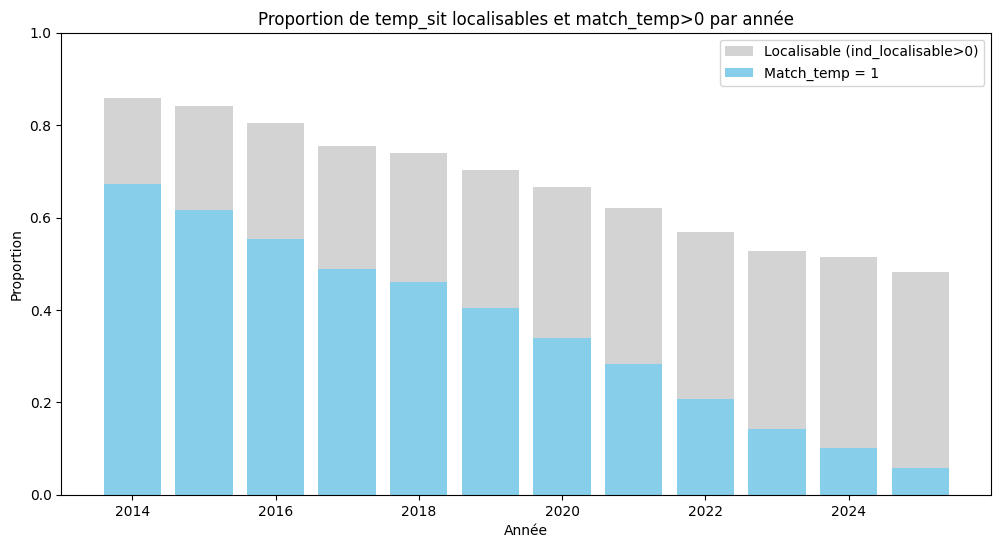

In [176]:
import matplotlib.pyplot as plt

# Récupérer les années
annees = sorted(temp_sit['ANNEE_REELLE_AUTORISATION'].dropna().unique())

# Calculer les proportions
prop_localisable = []
prop_matched = []

for annee in annees:
    subset = temp_sit[temp_sit['ANNEE_REELLE_AUTORISATION'] == annee]
    n_total = len(subset)
    
    if n_total == 0:
        prop_localisable.append(0)
        prop_matched.append(0)
    else:
        n_localisable = (subset['ind_localisable'] > 0).sum()
        n_matched = ((subset['ind_localisable'] > 0) & (subset['ind_match_BDTOPO'] > 0)).sum()
        
        prop_localisable.append(n_localisable / n_total)
        prop_matched.append(n_matched / n_total)

# Plot
plt.figure(figsize=(12,6))
plt.bar(annees, prop_localisable, color='lightgray', label='Localisable (ind_localisable>0)')
plt.bar(annees, prop_matched, color='skyblue', label='Match_temp = 1')
plt.xlabel('Année')
plt.ylabel('Proportion')
plt.title('Proportion de temp_sit localisables et match_temp>0 par année')
plt.ylim(0, 1)
plt.legend()
plt.show()

In [177]:
#EXPORT
import importlib
import os   
import BDTopo_fonctions
importlib.reload(BDTopo_fonctions)
from BDTopo_fonctions import upload_to_onyxia

output_file = "temp_BDTopo_hors_match_Sitadel.gpkg"
temp_BDTopo.to_file(output_file, driver="GPKG")
remote_path = f"Sitadel/{output_file}"
upload_to_onyxia(output_file, bucket="mgarbe", remote_path=remote_path)
os.remove(output_file)

output_file = "appariement_Sitadel2_BDTopo_fulldep_1000m3.gpkg"
temp_sit.to_file(output_file, driver="GPKG")
remote_path = f"Sitadel/{output_file}"
upload_to_onyxia(output_file, bucket="mgarbe", remote_path=remote_path)
os.remove(output_file)

[Upload] Envoi de temp_BDTopo_hors_match_Sitadel.gpkg vers mgarbe/Sitadel/temp_BDTopo_hors_match_Sitadel.gpkg ...
[Upload] Terminé avec succès
[Upload] Envoi de appariement_Sitadel2_BDTopo_fulldep_1000m3.gpkg vers mgarbe/Sitadel/appariement_Sitadel2_BDTopo_fulldep_1000m3.gpkg ...
[Upload] Terminé avec succès


### Création base pour clustering

Cette base regroupe tous les bâtiments de BD TOPO identifiés en 2013, tous ceux identifiés entre 2014 et 2025 hors matching avec Sitadel et les PC identifiables de Sitadel. 


Nous créons : 
* une variable B_geometry qui est le best guest de la geometry du bâti, après croisement Sitadel BDTopo

* une variable Annee_REF qui est l'année du dépôt du PC ou à défaut l'année d'identification du Bâti dans BDTopo

_Dans la majorité des cas, les colonnes sont propres à une base._

In [178]:
from BDTopo_fonctions import load_gpkg
temp_BDTopo=load_gpkg("Sitadel/temp_BDTopo_hors_match_Sitadel.gpkg")
temp_sit=load_gpkg("Sitadel/appariement_Sitadel2_BDTopo_fulldep_1000m3.gpkg")

Téléchargement depuis mgarbe/Sitadel/temp_BDTopo_hors_match_Sitadel.gpkg ...
Chargement réussi (84586 lignes)
Téléchargement depuis mgarbe/Sitadel/appariement_Sitadel2_BDTopo_fulldep_1000m3.gpkg ...
Chargement réussi (26921 lignes)


In [179]:
# GESTION DES DOUBLONS INTRODUITS EN 2019 DANS temp_BDTopo

import importlib
import appariement_Sitadel_BDTopo_fonctions
importlib.reload(appariement_Sitadel_BDTopo_fonctions)
from appariement_Sitadel_BDTopo_fonctions import fill_dep_BAN, doublons_temp_BDTopo

#supression des doublons introduits en 2019 avec l'extension des périmètres
temp_BDTopo=doublons_temp_BDTopo(temp_BDTopo)

#identification des départements et suppression des obs non identifiables
temp_BDTopo["Dep"]=temp_BDTopo["Dep"].astype("Int64")
temp_BDTopo=fill_dep_BAN(temp_BDTopo)
temp_BDTopo = temp_BDTopo[temp_BDTopo["Dep"].notna()].reset_index(drop=True)

Groupes doublons identifiés : 12605
Lignes supprimées : 15410
Complété 10586 valeurs NA de 'Dep'.


Appariement

In [180]:
from appariement_Sitadel_BDTopo_fonctions import parallel_stock_build
temp_stock2013=parallel_stock_build(gdf, annee_min=2008, annee_max=2013, rayon=10)

Traitement du dep 1
Traitement du dep 2
Traitement du dep 3
Traitement du dep 4
Traitement du dep 5
Traitement du dep 6
Traitement du dep 7
Traitement du dep 8
Traitement du dep 9
Traitement du dep 10
Traitement du dep 11
Traitement du dep 12
Traitement du dep 13
Traitement du dep 15

Traitement du dep 16
Traitement du dep 17
Traitement du dep 18
Traitement du dep 19
Traitement du dep 21
Traitement du dep 22
Traitement du dep 23
Traitement du dep 24
Traitement du dep 25
Traitement du dep 26
Traitement du dep 27
Traitement du dep 28
Traitement du dep 29
Traitement du dep 30
Traitement du dep 31
Traitement du dep 32
Traitement du dep 33
Traitement du dep 34
Traitement du dep 35
Traitement du dep 36
Traitement du dep 37
Traitement du dep 38
Traitement du dep 39
Traitement du dep 40
Traitement du dep 41
Traitement du dep 42
Traitement du dep 43
Traitement du dep 44
Traitement du dep 45
Traitement du dep 46
Traitement du dep 47
Traitement du dep 49

Traitement du dep 50
Traitement du dep 51

/home/onyxia/work/projet3A/appariement_Sitadel_BDTopo_fonctions.py:186: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  stock_df = gpd.GeoDataFrame(pd.concat(results, ignore_index=True), crs=gdf.crs)


In [181]:
#Mise en forme
temp_stock2013=temp_stock2013.rename(columns={"Dep": "DEP_CODE", "Annee":"Annee_Millésime","aire":"SURF_CREEE"})
temp_BDTopo=temp_BDTopo.rename(columns={"Dep": "DEP_CODE", "Annee":"Annee_Millésime","aire":"SURF_CREEE"})
temp_sit["Base"]="Sitadel"
temp_BDTopo["Base"]="BDTOPO"
temp_stock2013["Base"]="BDTOPO"

In [182]:
temp_BDTopo_concat = temp_BDTopo[['Base',
    'ID', 'DEP_CODE', 'ORIGIN_BAT', 'NATURE', 
    'USAGE1', 'Apparition_BDTopo', 'SOURCE', 
    'geometry', 'SURF_CREEE']].copy()

temp_stock2013_concat=temp_BDTopo_concat[['Base',
    'ID', 'DEP_CODE', 'ORIGIN_BAT', 'NATURE', 
    'USAGE1', 'Apparition_BDTopo', 'SOURCE', 
    'geometry', 'SURF_CREEE']].copy()

temp_sit_concat=temp_sit[temp_sit["ind_localisable"]==1].copy()

temp_sit_concat=temp_sit_concat[['Base','ANNEE_REELLE_AUTORISATION','DEP_CODE','COMM',
       'DATE_REELLE_AUTORISATION', 'DATE_REELLE_DOC', 'DATE_REELLE_DAACT','SURF_CREEE','I_EXTENSION','DESTINATION_PRINCIPALE','Apparition_BDTopo','geometry']].copy()

In [183]:
temp_concat=pd.concat([temp_sit_concat, temp_BDTopo_concat,temp_stock2013_concat], ignore_index=True)
temp_concat["ANNEE_REELLE_AUTORISATION"].astype("Int64")
temp_concat["Annee_REF"] = temp_concat["ANNEE_REELLE_AUTORISATION"].fillna(
    temp_concat["Apparition_BDTopo"]
).astype("Int64")
temp_concat.drop(
    columns=["ANNEE_REELLE_AUTORISATION", "Apparition_BDTopo"], 
    inplace=True
)

In [184]:
#EXPORT
import importlib
import os   
import BDTopo_fonctions
importlib.reload(BDTopo_fonctions)
from BDTopo_fonctions import upload_to_onyxia
output_file = "df_clustering_fulldep_1000m3.gpkg"
temp_concat.to_file(output_file, driver="GPKG")
remote_path = f"Sitadel/{output_file}"
upload_to_onyxia(output_file, bucket="mgarbe", remote_path=remote_path)
os.remove(output_file)

[Upload] Envoi de df_clustering_fulldep_1000m3.gpkg vers mgarbe/Sitadel/df_clustering_fulldep_1000m3.gpkg ...
[Upload] Terminé avec succès
